# Graph Analysis: Who Votes With Whom in the 119th Congress (2025–2026)

**Joao De Oliveira**

**Data:** [Voteview](https://voteview.com/data) (UCLA), the standard academic database of U.S. congressional votes. It is updated live as votes are taken, so every run of this notebook pulls the latest votes of the current Congress.

**Building the graph from text files.** Voteview provides three CSV files per chamber including members, individual votes, and roll-call metadata. I turn them into a network:
- **Node** is a member of Congress, with party, state, and dw nominate ideology score as attributes
- **Agreement** between two members is the share of roll calls (where both voted) on which they voted the same way
- **Edge** is the two members agree on at least `THRESHOLD` of those votes

**Research question:** How polarized is today's Congress, and who holds it together?

**Plan**
1. Load the CSVs, compute pairwise agreement, and build the co-voting graph
2. Analyze it: diameter, path length, clustering, party assortativity, cross-party bridges, centrality, and communities
3. Visualize the graph in Python and export a `.gexf` file for Gephi


## 0. Setup

In [1]:
!pip install -q pyvis

import os, urllib.request
from collections import deque, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.sparse.csgraph import connected_components
from pyvis.network import Network

pd.set_option("display.width", 140)
print("networkx version:", nx.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.3 MB/s eta 0:00:00
networkx version: 3.6.1


### Parameters
- `CHAMBER`: `S` gives the Senate (about 100 members). `H` gives the House (about 440 members).
- `THRESHOLD = None` picks the edge threshold automatically. It uses the highest agreement level at which the whole chamber still forms one connected network (step 1c).

In [2]:
CONGRESS   = 119
CHAMBER    = "S"
THRESHOLD  = None
MIN_SHARED = 50
MIN_VOTES  = 100

## 1. Load the data

In [3]:
BASE = "https://voteview.com/static/data/out"

def load_csv(kind):
    fname = f"{CHAMBER}{CONGRESS}_{kind}.csv"
    if not os.path.exists(fname):
        url = f"{BASE}/{kind}/{fname}"
        print("Downloading", url)
        urllib.request.urlretrieve(url, fname)
    return pd.read_csv(fname)

members   = load_csv("members")
votes     = load_csv("votes")
rollcalls = load_csv("rollcalls")

chamber_name = {"S": "Senate", "H": "House"}[CHAMBER]
members = members[members["chamber"] == chamber_name].copy()        # drop president's row
votes   = votes[votes["chamber"] == chamber_name]

print(f"{chamber_name}, {CONGRESS}th Congress")
print(f"Roll calls: {votes['rollnumber'].nunique():,}  "
      f"({rollcalls['date'].min()} to {rollcalls['date'].max()})")
print(f"Members on file: {len(members)} | individual vote records: {len(votes):,}")

Senate, 119th Congress
Roll calls: 915  (2025-01-09 to 2026-09-30)
Members on file: 104 | individual vote records: 91,633


### 1a. Clean up member labels and parties
Voteview party codes: 100 = Democrat, 200 = Republican, 328 = Independent. Independents in the Senate caucus with Democrats, so I analyze polarization by caucus, while still showing independents in their own color.

In [4]:
PARTY  = {100: "Democrat", 200: "Republican", 328: "Independent"}
CAUCUS = {100: "Democratic caucus", 200: "Republican", 328: "Democratic caucus"}
COLOR  = {"Democrat": "#2166ac", "Republican": "#d6604d", "Independent": "#7b3294"}

def short_label(row):
    last = row["bioname"].split(",")[0].title()
    p = PARTY.get(row["party_code"], "Other")[0]
    seat = row["state_abbrev"] + (str(int(row["district_code"])) if CHAMBER == "H" else "")
    return f"{last} ({p}-{seat})"

members["party"]  = members["party_code"].map(PARTY).fillna("Other")
members["caucus"] = members["party_code"].map(CAUCUS).fillna("Other")
members["label"]  = members.apply(short_label, axis=1)
dups = members["label"].duplicated(keep=False)
members.loc[dups, "label"] += " " + members.loc[dups, "bioname"].str.split(", ").str[1].str[0] + "."

# vote matrix: rows = members and columns = roll calls
cast = votes["cast_code"].map({1: 1, 2: 1, 3: 1, 4: -1, 5: -1, 6: -1}).fillna(0)
V = (votes.assign(v=cast)
          .pivot_table(index="icpsr", columns="rollnumber", values="v", aggfunc="first", fill_value=0))

n_cast = (V != 0).sum(axis=1)
keep = n_cast[n_cast >= MIN_VOTES].index.intersection(members["icpsr"])
V = V.loc[keep]
members = members.set_index("icpsr").loc[keep]

dropped = set(votes["icpsr"].unique()) - set(keep)
print(f"Members kept: {len(keep)} (dropped {len(dropped)} with < {MIN_VOTES} votes cast)")
print(members["party"].value_counts().to_string())

Members kept: 101 (dropped 4 with < 100 votes cast)
party
Republican     54
Democrat       45
Independent     2


### 1b. Pairwise agreement
For members *i* and *j*: agreement = (roll calls where both voted yea, plus roll calls where both voted nay) ÷ (roll calls where both voted).
Matrix multiplication computes all pairs at once.

In [5]:
X = V.values
Y = (X == 1).astype(np.int32); N = (X == -1).astype(np.int32); B = (X != 0).astype(np.int32)
agree_cnt  = Y @ Y.T + N @ N.T
shared_cnt = B @ B.T
with np.errstate(divide="ignore", invalid="ignore"):
    A = np.where(shared_cnt >= MIN_SHARED, agree_cnt / shared_cnt, np.nan)
np.fill_diagonal(A, np.nan)

ids    = list(V.index)
label  = members["label"].to_dict()
caucus = members["caucus"].to_dict()
same = np.equal.outer(members["caucus"].values, members["caucus"].values)
iu = np.triu_indices_from(A, k=1)
print(f"Average agreement, same caucus:     {np.nanmean(A[iu][same[iu]]):.1%}")
print(f"Average agreement, opposite caucus: {np.nanmean(A[iu][~same[iu]]):.1%}")

Average agreement, same caucus:     94.3%
Average agreement, opposite caucus: 11.4%


### 1c. Choosing the edge threshold and building the graph


Automatic threshold (connectivity bottleneck): 0.394


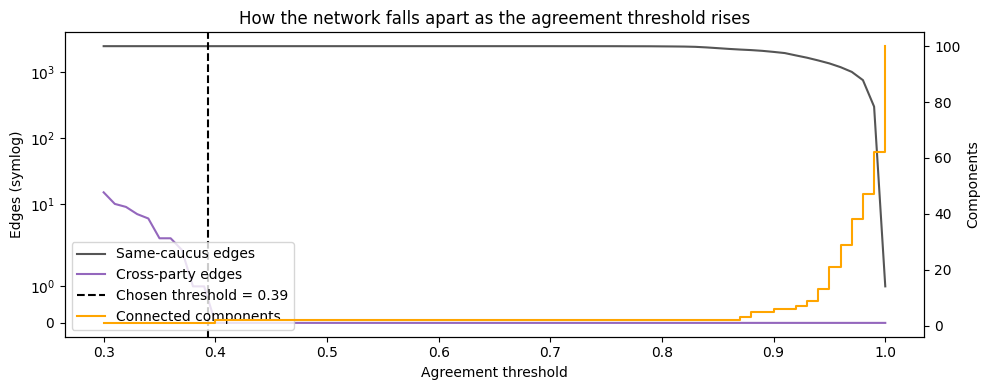

Cross-party edges vanish entirely above agreement ~0.39


In [6]:
W = np.nan_to_num(A, nan=0.0)

def n_components_at(t):
    return connected_components((W >= t).astype(np.int8), directed=False)[0]

if THRESHOLD is None:
    full = nx.Graph()
    full.add_weighted_edges_from((ids[i], ids[j], W[i, j]) for i, j in zip(*iu) if W[i, j] > 0)
    mst = nx.maximum_spanning_tree(full)
    THRESHOLD = min(d["weight"] for *_, d in mst.edges(data=True))
    print(f"Automatic threshold (connectivity bottleneck): {THRESHOLD:.3f}")

grid = np.round(np.arange(0.30, 1.001, 0.01), 2)
sweep = pd.DataFrame({
    "threshold": grid,
    "components": [n_components_at(t) for t in grid],
    "cross_party_edges": [int(((W[iu] >= t) & ~same[iu]).sum()) for t in grid],
    "same_party_edges":  [int(((W[iu] >= t) &  same[iu]).sum()) for t in grid],
})
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(sweep.threshold, sweep.same_party_edges, label="Same-caucus edges", color="#555")
ax1.plot(sweep.threshold, sweep.cross_party_edges, label="Cross-party edges", color="#9467bd")
ax1.set_yscale("symlog"); ax1.set_xlabel("Agreement threshold"); ax1.set_ylabel("Edges (symlog)")
ax2 = ax1.twinx(); ax2.step(sweep.threshold, sweep.components, where="post", color="orange", label="Connected components")
ax2.set_ylabel("Components")
ax1.axvline(THRESHOLD, color="black", ls="--", label=f"Chosen threshold = {THRESHOLD:.2f}")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower left")
plt.title("How the network falls apart as the agreement threshold rises"); plt.tight_layout(); plt.show()

last_cross = sweep.loc[sweep.cross_party_edges > 0, "threshold"].max()
print(f"Cross-party edges vanish entirely above agreement ~{last_cross:.2f}")

In [7]:
# graph
G = nx.Graph()
for icpsr, row in members.iterrows():
    G.add_node(row["label"], icpsr=int(icpsr), party=row["party"], caucus=row["caucus"],
               state=row["state_abbrev"],
               nominate=float(row["nominate_dim1"]) if pd.notna(row["nominate_dim1"]) else 0.0)
for i, j in zip(*iu):
    if W[i, j] >= THRESHOLD:
        G.add_edge(label[ids[i]], label[ids[j]], agreement=round(float(W[i, j]), 4))

party_of  = nx.get_node_attributes(G, "party")
caucus_of = nx.get_node_attributes(G, "caucus")
print(f"Graph: {G.number_of_nodes()} members, {G.number_of_edges():,} edges | connected: {nx.is_connected(G)}")

Graph: 101 members, 2,512 edges | connected: True


## 2. Basic analysis

### 2a. Diameter: hand-coded vs. networkx
- **Eccentricity** of a member  -the most hops needed to reach any other member
- **Diameter** - the largest eccentricity; radius = the smallest

The graph is unweighted, so one BFS per node gives all of that node's shortest distances.

In [8]:
def bfs_distances(G, source):
    dist = {source: 0}
    queue = deque([source])
    while queue:
        u = queue.popleft()
        for v in G.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist

all_dist = {n: bfs_distances(G, n) for n in G.nodes()}
ecc = {n: max(d.values()) for n, d in all_dist.items()}
diam_mine, rad_mine = max(ecc.values()), min(ecc.values())
diam_nx, rad_nx = nx.diameter(G), nx.radius(G)

print(f"Diameter -> hand-coded: {diam_mine} | networkx: {diam_nx}")
print(f"Radius   -> hand-coded: {rad_mine} | networkx: {rad_nx}")
assert (diam_mine, rad_mine) == (diam_nx, rad_nx), "Mismatch!"
print("Hand-coded BFS matches networkx")

Diameter -> hand-coded: 3 | networkx: 3
Radius   -> hand-coded: 2 | networkx: 2
Hand-coded BFS matches networkx


In [9]:
u = max(ecc, key=ecc.get)
v = max(all_dist[u], key=all_dist[u].get)
diameter_path = nx.shortest_path(G, u, v)
path_edges = list(zip(diameter_path, diameter_path[1:]))

print(f"Longest shortest path ({diam_nx} hops):")
for a, b in path_edges:
    print(f"  {a:<28} --({G[a][b]['agreement']:.0%} agreement)--> {b}")
center = sorted(n for n, e in ecc.items() if e == rad_nx)
print(f"\nCenter (eccentricity {rad_nx}): {len(center)} members, e.g. {center[:6]}")
print("Eccentricity distribution:", dict(sorted(Counter(ecc.values()).items())))

Longest shortest path (3 hops):
  Grassley (R-IA)              --(86% agreement)--> Collins (R-ME)
  Collins (R-ME)               --(39% agreement)--> Fetterman (D-PA)
  Fetterman (D-PA)             --(76% agreement)--> Markey (D-MA)

Center (eccentricity 2): 2 members, e.g. ['Collins (R-ME)', 'Fetterman (D-PA)']
Eccentricity distribution: {2: 2, 3: 99}


### 2b. Global metrics

In [10]:
degrees = dict(G.degree())
summary = {
    "Members (nodes)":                G.number_of_nodes(),
    "Co-voting ties (edges)":         G.number_of_edges(),
    "Agreement threshold":            round(THRESHOLD, 3),
    "Density":                        round(nx.density(G), 4),
    "Average degree":                 round(np.mean(list(degrees.values())), 2),
    "Diameter":                       diam_nx,
    "Radius":                         rad_nx,
    "Average shortest path length":   round(nx.average_shortest_path_length(G), 3),
    "Average clustering coefficient": round(nx.average_clustering(G), 4),
    "Transitivity (global clustering)": round(nx.transitivity(G), 4),
}
pd.DataFrame(summary.items(), columns=["Metric", "Value"]).astype({"Value": object})

,Metric,Value
0,Members (nodes),101.0
1,Co-voting ties (edges),2512.0
2,Agreement threshold,0.394
3,Density,0.4974
4,Average degree,49.74
5,Diameter,3.0
6,Radius,2.0
7,Average shortest path length,1.985
8,Average clustering coefficient,0.9988
9,Transitivity (global clustering),0.9988


### 2c. Polarization metrics
- Cross-party ties: edges linking the Democratic caucus to Republicans. If ties ignored party, roughly half would cross.
- Caucus assortativity: 0 means ties are random with respect to party, and +1 means members only tie to their own side.
- Bridges: the members holding the cross-party ties.

In [11]:
cross_edges = [(a, b, G[a][b]["agreement"]) for a, b in G.edges() if caucus_of[a] != caucus_of[b]]
sizes = Counter(caucus_of.values()); n = G.number_of_nodes()
expected = 2 * sizes["Democratic caucus"] * sizes["Republican"] / (n * (n - 1))
assort = nx.attribute_assortativity_coefficient(G, "caucus")

within, across = [], []
for s, dist in all_dist.items():
    for t, d in dist.items():
        if s < t:
            (within if caucus_of[s] == caucus_of[t] else across).append(d)

display(pd.DataFrame({"Value": [
    f"{len(cross_edges)} of {G.number_of_edges():,} ({len(cross_edges) / G.number_of_edges():.2%})",
    f"{expected:.1%}",
    round(assort, 3),
    round(np.mean(within), 2),
    round(np.mean(across), 2)]},
    index=["Cross-party ties", "Expected if party didn't matter", "Caucus assortativity",
           "Avg hops, same caucus", "Avg hops, opposite caucus"]))

print("Cross-party ties at this threshold:")
for a, b, w in sorted(cross_edges, key=lambda e: -e[2]):
    print(f"  {a:<28} <-> {b:<28} {w:.1%}")

,Value
Cross-party ties,"1 of 2,512 (0.04%)"
Expected if party didn't matter,50.3%
Caucus assortativity,0.999
"Avg hops, same caucus",1.0
"Avg hops, opposite caucus",2.96


Cross-party ties at this threshold:
  Fetterman (D-PA)             <-> Collins (R-ME)               39.4%


In [12]:
rows = []
for i, m in enumerate(ids):
    other = [j for j in range(len(ids)) if caucus[ids[j]] != caucus[m] and not np.isnan(A[i, j])]
    if other:
        j = max(other, key=lambda j: A[i, j])
        rows.append({"member": label[m], "party": members.loc[m, "party"],
                     "closest cross-party ally": label[ids[j]], "agreement": A[i, j]})
allies = pd.DataFrame(rows).sort_values("agreement", ascending=False)
print("Members with the highest agreement with someone from the other side:")
display(allies.head(10).style.format({"agreement": "{:.1%}"}).hide(axis="index"))

Members with the highest agreement with someone from the other side:


member,party,closest cross-party ally,agreement
Fetterman (D-PA),Democrat,Collins (R-ME),39.4%
Collins (R-ME),Republican,Fetterman (D-PA),39.4%
Murkowski (R-AK),Republican,Fetterman (D-PA),37.5%
Shaheen (D-NH),Democrat,Collins (R-ME),36.4%
King (I-ME),Independent,Collins (R-ME),34.9%
Hassan (D-NH),Democrat,Collins (R-ME),34.6%
Rosen (D-NV),Democrat,Collins (R-ME),32.3%
Gallego (D-AZ),Democrat,Collins (R-ME),31.4%
Warner (D-VA),Democrat,Collins (R-ME),30.7%
Cortez Masto (D-NV),Democrat,Collins (R-ME),30.7%


### 2d. Node-level metrics

In [13]:
btw_c   = nx.betweenness_centrality(G)
close_c = nx.closeness_centrality(G)
clust   = nx.clustering(G)

nodes_df = pd.DataFrame({
    "party": party_of,
    "degree": degrees,
    "betweenness": btw_c,
    "closeness": close_c,
    "clustering": clust,
    "eccentricity": ecc,
    "nominate_dim1": nx.get_node_attributes(G, "nominate"),
}).rename_axis("member")
nodes_df["cross_party_ties"] = pd.Series(Counter([a for a, b, _ in cross_edges] + [b for a, b, _ in cross_edges]))
nodes_df["cross_party_ties"] = nodes_df["cross_party_ties"].fillna(0).astype(int)

print("Top 10 by betweenness (brokers between groups)")
display(nodes_df.sort_values("betweenness", ascending=False).head(10).round(4))
print("Top 10 by degree (votes with the most colleagues)")
display(nodes_df.sort_values("degree", ascending=False).head(10).round(4))

Top 10 by betweenness (brokers between groups)


,party,degree,betweenness,closeness,clustering,eccentricity,nominate_dim1,cross_party_ties
member,,,,,,,,
Collins (R-ME),Republican,54,0.5032,0.6849,0.9623,2,0.124,1
Fetterman (D-PA),Democrat,47,0.5018,0.6536,0.9574,2,-0.177,1
Blackburn (R-TN),Republican,53,0.0000,0.5181,0.9993,3,0.632,0
Mcconnell (R-KY),Republican,53,0.0000,0.5181,0.9993,3,0.402,0
Grassley (R-IA),Republican,53,0.0000,0.5181,0.9993,3,0.363,0
Banks (R-IN),Republican,53,0.0000,0.5181,0.9993,3,0.649,0
Budd (R-NC),Republican,53,0.0000,0.5181,0.9993,3,0.634,0
Marshall (R-KS),Republican,53,0.0000,0.5181,0.9993,3,0.606,0
Cassidy (R-LA),Republican,53,0.0000,0.5181,0.9993,3,0.463,0


Top 10 by degree (votes with the most colleagues)


,party,degree,betweenness,closeness,clustering,eccentricity,nominate_dim1,cross_party_ties
member,,,,,,,,
Collins (R-ME),Republican,54,0.5032,0.6849,0.9623,2,0.124,1
Mcconnell (R-KY),Republican,53,0.0000,0.5181,0.9993,3,0.402,0
Blackburn (R-TN),Republican,53,0.0000,0.5181,0.9993,3,0.632,0
Capito (R-WV),Republican,53,0.0000,0.5181,0.9993,3,0.285,0
Grassley (R-IA),Republican,53,0.0000,0.5181,0.9993,3,0.363,0
Banks (R-IN),Republican,53,0.0000,0.5181,0.9993,3,0.649,0
Budd (R-NC),Republican,53,0.0000,0.5181,0.9993,3,0.634,0
Marshall (R-KS),Republican,53,0.0000,0.5181,0.9993,3,0.606,0
Cassidy (R-LA),Republican,53,0.0000,0.5181,0.9993,3,0.463,0


### 2e. Community detection: does the algorithm find the parties by itself?
Louvain uses only the co voting ties and never sees party labels

In [14]:
communities = sorted(nx.community.louvain_communities(G, seed=42), key=len, reverse=True)
community_of = {m: i for i, c in enumerate(communities) for m in c}
nodes_df["community"] = pd.Series(community_of)
modularity = nx.community.modularity(G, communities)
caucus_split = [{m for m in G if caucus_of[m] == c} for c in set(caucus_of.values())]
print(f"Louvain: {len(communities)} communities, modularity {modularity:.3f}")
print(f"Caucus split modularity: {nx.community.modularity(G, caucus_split):.3f}")
comp = pd.crosstab(nodes_df["community"], nodes_df["party"])
comp["size"] = comp.sum(axis=1)
display(comp)

Louvain: 2 communities, modularity 0.490
Caucus split modularity: 0.490


party,Democrat,Independent,Republican,size
community,,,,
0,0,0,54,54
1,45,2,0,47


## 3. Visualization

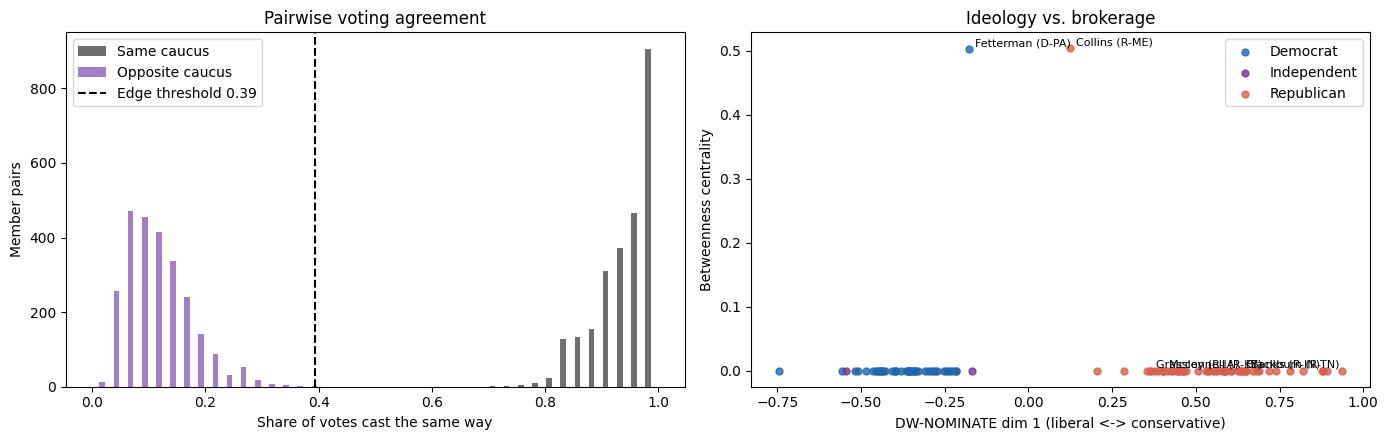

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# same vs opposite caucus
axes[0].hist([A[iu][same[iu]], A[iu][~same[iu]]], bins=40, range=(0, 1),
             color=["#555", "#9467bd"], label=["Same caucus", "Opposite caucus"], alpha=0.85)
axes[0].axvline(THRESHOLD, color="black", ls="--", label=f"Edge threshold {THRESHOLD:.2f}")
axes[0].set_title("Pairwise voting agreement"); axes[0].set_xlabel("Share of votes cast the same way")
axes[0].set_ylabel("Member pairs"); axes[0].legend()

# are brokers the moderates?
for p, grp in nodes_df.groupby("party"):
    axes[1].scatter(grp.nominate_dim1, grp.betweenness, color=COLOR.get(p, "gray"), label=p, alpha=0.8, s=25)
for m in nodes_df.sort_values("betweenness", ascending=False).head(6).index:
    axes[1].annotate(m, (nodes_df.loc[m, "nominate_dim1"], nodes_df.loc[m, "betweenness"]), fontsize=8,
                     xytext=(4, 2), textcoords="offset points")
axes[1].set_title("Ideology vs. brokerage"); axes[1].set_xlabel("DW-NOMINATE dim 1 (liberal <-> conservative)")
axes[1].set_ylabel("Betweenness centrality"); axes[1].legend()
plt.tight_layout(); plt.show()

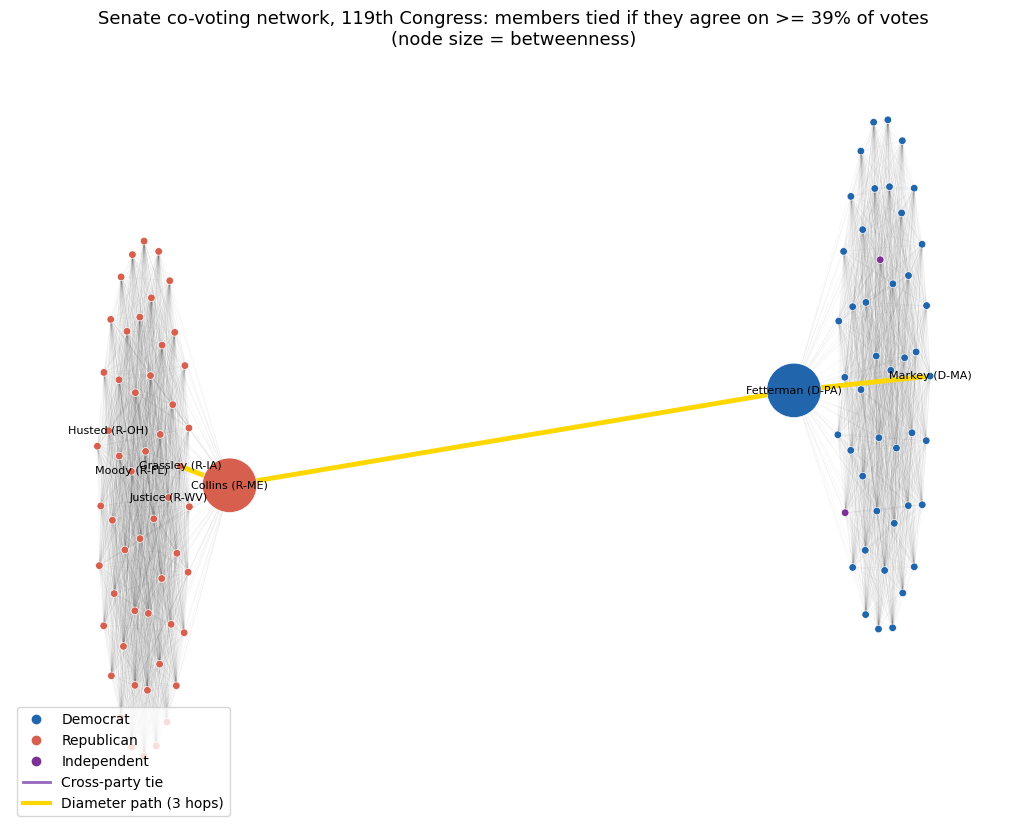

In [16]:
# network: color = party, size = betweenness, gold = diameter path, purple = cross-party ties
pos = nx.spring_layout(G, seed=7, k=1.5 / np.sqrt(G.number_of_nodes()), iterations=200)
colors = [COLOR.get(party_of[m], "gray") for m in G]
sizes_ = [30 + 3000 * btw_c[m] for m in G]
bridge_nodes = set(nodes_df.index[nodes_df.cross_party_ties > 0])

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.04, width=0.5)
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(a, b) for a, b, _ in cross_edges], edge_color="#9467bd", width=1.5)
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=path_edges, edge_color="gold", width=3.5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes_, edgecolors="white", linewidths=0.5)
to_label = bridge_nodes | set(diameter_path) | set(nodes_df.sort_values("betweenness").tail(5).index)
nx.draw_networkx_labels(G, pos, ax=ax, labels={m: m for m in to_label}, font_size=8)
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=c, label=p) for p, c in COLOR.items() if p in party_of.values()] +
                  [Line2D([], [], color="#9467bd", lw=2, label="Cross-party tie"),
                   Line2D([], [], color="gold", lw=3, label=f"Diameter path ({diam_nx} hops)")], loc="lower left")
ax.set_title(f"{chamber_name} co-voting network, {CONGRESS}th Congress: members tied if they agree on "
             f">= {THRESHOLD:.0%} of votes\n(node size = betweenness)", fontsize=13)
ax.axis("off"); plt.show()

### 3b. Interactive view and Gephi export
- **`congress_interactive.html`** opens in a browser. Hover over a member to see party, state, ideology, and centrality.
- **`congress_network.gexf`** opens in Gephi with every metric attached.

In [17]:
on_path = set(diameter_path)
for m in G:
    G.nodes[m].update(community=int(community_of[m]), degree=int(degrees[m]), betweenness=float(btw_c[m]),
                      closeness=float(close_c[m]), clustering=float(clust[m]), eccentricity=int(ecc[m]),
                      cross_party_ties=int(nodes_df.loc[m, "cross_party_ties"]), on_diameter_path=int(m in on_path))
nx.write_gexf(G, "congress_network.gexf")

net = Network(height="800px", width="100%", notebook=False, cdn_resources="in_line")
for m in G:
    net.add_node(m, label=m, size=8 + 120 * btw_c[m] ** 0.5,
                 color="#f5c518" if m in on_path else COLOR.get(party_of[m], "gray"),
                 title=f"{m} | {party_of[m]} | NOMINATE {G.nodes[m]['nominate']:+.2f} | "
                       f"degree {degrees[m]} | betweenness {btw_c[m]:.3f}")
cross_set = {frozenset((a, b)) for a, b, _ in cross_edges}
for a, b, d in G.edges(data=True):
    is_cross = frozenset((a, b)) in cross_set
    net.add_edge(a, b, title=f"{d['agreement']:.1%} agreement",
                 color="#9467bd" if is_cross else "#e0e0e0", width=3 if is_cross else 0.3)
net.barnes_hut(gravity=-6000, spring_length=120)
net.write_html("congress_interactive.html")
print("Wrote congress_network.gexf and congress_interactive.html")

try:
    from google.colab import files
    files.download("congress_network.gexf"); files.download("congress_interactive.html")
except ImportError:
    pass

Wrote congress_network.gexf and congress_interactive.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Summary

In [18]:
top_broker = nodes_df["betweenness"].idxmax()
print("=" * 72)
print(f"{chamber_name}, {CONGRESS}th Congress — votes through {rollcalls['date'].max()}")
print(f"Graph:                {G.number_of_nodes()} members, {G.number_of_edges():,} ties (agree >= {THRESHOLD:.1%})")
print(f"Diameter / radius:    {diam_nx} / {rad_nx} | avg shortest path {summary['Average shortest path length']}")
print(f"Avg clustering:       {summary['Average clustering coefficient']}")
print(f"Cross-party ties:     {len(cross_edges)} ({len(cross_edges) / G.number_of_edges():.2%}; ~{expected:.0%} if party didn't matter)")
print(f"Caucus assortativity: {assort:.3f}")
print(f"Louvain communities:  {len(communities)}, modularity {modularity:.3f}")
print(f"Top broker:           {top_broker} (betweenness {btw_c[top_broker]:.3f})")
print("=" * 72)

Senate, 119th Congress — votes through 2026-09-30
Graph:                101 members, 2,512 ties (agree >= 39.4%)
Diameter / radius:    3 / 2 | avg shortest path 1.985
Avg clustering:       0.9988
Cross-party ties:     1 (0.04%; ~50% if party didn't matter)
Caucus assortativity: 0.999
Louvain communities:  2, modularity 0.490
Top broker:           Collins (R-ME) (betweenness 0.503)


## 5. Takeaways

**1. The data is current.** The network covers all 909 Senate roll calls from January 9, 2025 to September 28, 2026. It includes 101 senators because one seat changed hands during this Congress and both senators cast 100+ votes.

**2. Two separate voting worlds.** Senators in the same caucus vote together 94.3% of the time on average. Across the aisle, that drops to 11.4%.

**3. A single tie holds the Senate together.** The automatic threshold (39.4% agreement) is the highest level at which all 101 senators still form one connected network. At that level there are 2,512 ties, and only one of them crosses party lines: Susan Collins (R-ME) and John Fetterman (D-PA)**, who agree on 39.4% of their shared votes. If ties ignored party, about 50% would cross. Caucus assortativity is 0.999, where 1.0 means complete segregation. Raise the threshold above 39.4% and the Senate splits into two disconnected party blocs.

**4. Diameter = 3, radius = 2.** The longest shortest path runs Grassley (R-IA) → Collins (R-ME) → Fetterman (D-PA) → Markey (D-MA). Every path between the parties has to pass through the Collins–Fetterman tie. As a result, Collins and Fetterman are the only two senators with eccentricity 2 (the network's center), and all 99 others have eccentricity 3. Senators in the same caucus are 1.0 hop apart on average, while senators in opposite caucuses are 2.96 hops apart, which is nearly the maximum possible.

**5. Each party is a near perfect clique.** The average clustering coefficient is 0.999. Every Republican is tied to every other Republican, and within the Democratic caucus only one pair of senators falls below the threshold. The density of 0.497 is almost exactly what two complete, separate cliques of 54 and 47 members would produce.

**6. Two brokers, and they're moderates.** Collins (betweenness 0.503) and Fetterman (0.502) are the only senators with any betweenness, every other senator scores 0. They are also among the most moderate members of their parties by DW-NOMINATE (Collins +0.124, Fetterman −0.177, on a scale running from −1, most liberal, to +1, most conservative).

**7. The next closest bridges.** The strongest remaining cross-party pairs are Murkowski (R-AK)–Fetterman (37.7%), and Collins with Shaheen (36.6%), King (35.0%) and Hassan (34.6%). Lowering the threshold to about 35% would add them. Collins is the closest Republican ally for most of the Democrats in the top 10.

**8. The algorithm rediscovers the parties perfectly.** Using only the co-voting ties, Louvain finds exactly 2 communities. One contains all 54 Republicans, and the other contains all 45 Democrats plus the 2 Independents. Its modularity (0.490) is identical to that of the actual party split.

**Bottom line:** In the current Senate, partisanship is not just strong but almost total. At the tightest level where the chamber still forms one network, it is two closed blocs connected by one relationship.
